## Cell type annotation

UniST performs cell type annotation by transferring labels from original cells to newly generated synthetic coordinates via KNN search in a hybrid space that combines transcriptomic embeddings (from GAE-INR) and spatial coordinates.

In [1]:
!git clone https://github.com/lanshui98/UniST.git
%cd UniST

Cloning into 'UniST'...
remote: Enumerating objects: 360, done.
remote: Counting objects: 100% (360/360), done.
remote: Compressing objects: 100% (322/322), done.
remote: Total 360 (delta 140), reused 179 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (360/360), 7.42 MiB | 12.60 MiB/s, done.
Resolving deltas: 100% (140/140), done.
/content/UniST


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2

In [3]:
! pip install scanpy

In [4]:
import random
import seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scanpy as sc

#### We illustrate the cell annotation using Spateo 2D slice.

In [ ]:
%cd external/SUICA_pro

In [11]:
adata_path = 'data/slice_440.h5ad'
slice = sc.read(adata_path)

In [12]:
slice

View of AnnData object with n_obs × n_vars = 8382 × 17649
    obs: 'area', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'louvain', 'transf_anno_E95', 'mapped_celltype', 'head_or_body', 'heart_region'
    obsm: '3d_align_spatial', 'X_pca', 'bbox', 'global_align_spatial', 'spatial'

In [22]:
#### all the cell types

anno_colors = {
        "Sclerotome": "#2DA048", "Dermomyotome": "#C49C94", "Lateral plate mesoderm": "#1F77B4", "Limb progenitors and lateral plate mesoderm": "#A1C299",
        "Head and facial mesenchyme": "#F57E20", "Cranial mesoderm": "#9268AC", "Gut mesenchyme": "#8C574C", "Cardiopharyngeal mesoderm": "#DBDB8C",
        "Renal mesenchyme": "#1DBFCF", "Mesodermal progenitors": "#4C64AE", "Hepatic mesenchyme": "#FF00FF", "Intermediate mesoderm": "#E5E4E2",
        "Anterior intermediate mesoderm": "#FCB415", "Primitive erythroid cells": "#FCBA78", "Hematoendothelial progenitors": "#456D75",
        "Endothelium": "#D52928", "Arterial endothelial cells": "#F8A993",  'Liver sinusoidal endothelial cell precursors':"#CAE8E1",
        "Liver sinusoidal endothelial cells": "#CAE8E1", "Vessel endothelial cells": "#0E1033",
        "Epithelial precursors": "#AEC7E8", "Placode and neural crest-derived": "#F69696", "Gut": "#4B3B53", "Otic epithelial cells": "#003349",
        "Olfactory epithelial cells": "#CC1F47", "Amniotic ectoderm": "#352411", "Hepatocytes": "#0C2013", "Ectoderm-derived": "#C7DF92",
        "Glutamatergic neurons": "#D06327", "Spinal cord motor neurons": "#05A6D8", "Cranial motor neurons": "#A079B6", "Neural progenitor cells": "#A93493",
        "Spinal cord ventral progenitors": "#E0C4DE", "Spinal cord dorsal progenitors": "#798D66", "Telencephalon neuroectoderm": "#F6B5D1",
        "Spinal cord neuroectoderm": "#9ED089", "Midbrain neuroectoderm": "#7F7F7F", "Hindbrain neuroectoderm": "#C4B0D5", "Midbrain-hindbrain boundary": "#C7C7C6",
        "Diencephalon neuroectoderm": "#7B504B", "Hypothalamus neuroectoderm": "#DEEEFA", "Hypothalamus (Sim1+) neuroectoderm": "#038470",
        "Dorsal telencephalon neuroectoderm": "#124B99", "Neuroectoderm-derived": "#BCBD32", "Anterior floor plate": "#C0B9B2", "Anterior roof plate": "#2B0F1B",
        "Posterior roof plate": "#6C2062", "Eye field": "#62615A", "NMPs and spinal cord progenitors": "#EE3780", "Neural crest (PNS glia)": "#9FDAE5",
        "Neural crest (PNS neurons)": "#6B7A34", "LV/atrioventricular canal/common atrium cardiomyocytes": "#FF0000", "Second heart field-derived cardiomyocytes": "#FF0000",
        "Proepicardium": "#FF0000", "Endocardial cells": "#FF0000"
}

Text(0.5, 1.0, 'Cell Types, Slice 440, 8382 cells')

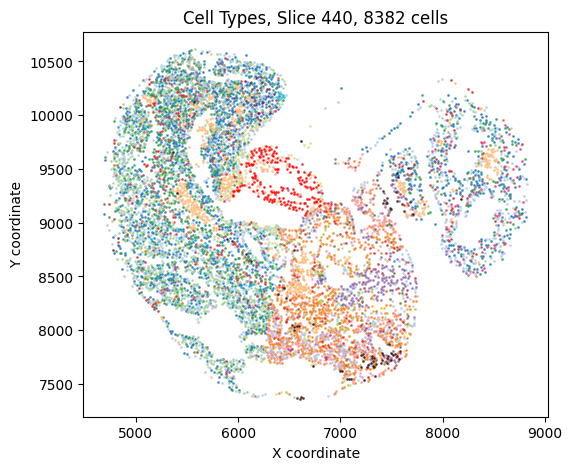

In [66]:
spatial_coords = slice.obsm['global_align_spatial']
x_coords = spatial_coords[:, 0]
y_coords = spatial_coords[:, 1]

cell_types = slice.obs['mapped_celltype']

# Get unique types in this slice
unique_types = cell_types.unique()
n_types = len(unique_types)

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))

for cell_type in unique_types:
    mask = cell_types == cell_type
    ax1.scatter(x_coords[mask], y_coords[mask],
               c=[anno_colors[cell_type]],
               label=cell_type,
               s=1, alpha=0.7)

ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')
ax1.set_title(f'Cell Types, Slice 440, {slice.shape[0]} cells')

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

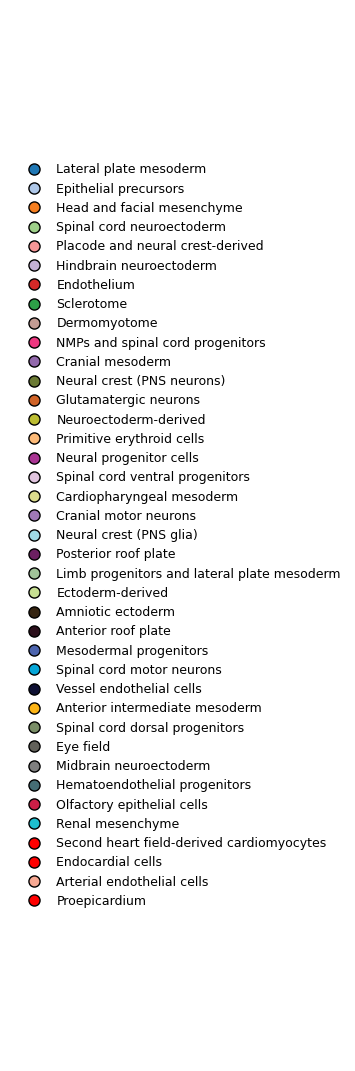

In [26]:
from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        label=cell_type,
        markerfacecolor=anno_colors[cell_type],
        markersize=8
    )
    for cell_type in unique_types
]

fig_leg, ax_leg = plt.subplots(figsize=(4, 0.35 * len(unique_types)))
ax_leg.legend(
    handles=legend_elements,
    loc='center left',
    frameon=False,
    fontsize=9
)
ax_leg.axis('off')

In [13]:
### Mapping cell types to 9 major cell types according to Spateo paper

celltype_to_9major = {
    "Spinal cord motor neurons": "CNS neurons",
    "Spinal cord dorsal progenitors": "CNS neurons",
    "Spinal cord ventral progenitors": "CNS neurons",
    "Cranial motor neurons": "CNS neurons",
    "Glutamatergic neurons": "CNS neurons",
    "Neural progenitor cells": "CNS neurons",
    "Neuroectoderm-derived": "CNS neurons",
    "Neural crest (PNS neurons)": "PNS neurons",
    "Neural crest (PNS glia)": "PNS glia",
    "Epithelial precursors": "Epithelium",
    "Placode and neural crest-derived": "Epithelium",
    "Ectoderm-derived": "Epithelium",
    "Amniotic ectoderm": "Epithelium",
    "Anterior intermediate mesoderm": "Epithelium",
    "Intermediate mesoderm": "Epithelium",
    "Olfactory epithelial cells": "Epithelium",
    "Otic epithelial cells": "Epithelium",
    "Gut": "Epithelium",
    "Endothelium": "Endothelium",
    "Vessel endothelial cells": "Endothelium",
    "Arterial endothelial cells": "Endothelium",
    "Hematoendothelial progenitors": "Endothelium",
    "Endocardial cells": "Endothelium",
    "Liver sinusoidal endothelial cell precursors": "Endothelium",
    "Primitive erythroid cells": "Blood lineages",
    "Second heart field-derived cardiomyocytes": "Cardiomyocytes",
    "LV/atrioventricular canal/common atrium cardiomyocytes": "Cardiomyocytes",
    "Cranial mesoderm": "Mesoderm",
    "Head and facial mesenchyme": "Mesoderm",
    "Cardiopharyngeal mesoderm": "Mesoderm",
    "Dermomyotome": "Mesoderm",
    "Lateral plate mesoderm": "Mesoderm",
    "Sclerotome": "Mesoderm",
    "Proepicardium": "Mesoderm",
    "Mesodermal progenitors": "Mesoderm",
    "Hepatic mesenchyme": "Mesoderm",
    "Gut mesenchyme": "Mesoderm",
    "Renal mesenchyme": "Mesoderm",
    "Limb progenitors and lateral plate mesoderm": "Mesoderm",
    "Spinal cord neuroectoderm": "Neuroectoderm",
    "Hindbrain neuroectoderm": "Neuroectoderm",
    "Midbrain-hindbrain boundary": "Neuroectoderm",
    "Midbrain neuroectoderm": "Neuroectoderm",
    "Telencephalon neuroectoderm": "Neuroectoderm",
    "Diencephalon neuroectoderm": "Neuroectoderm",
    "Hypothalamus (Sim1+) neuroectoderm": "Neuroectoderm",
    "Hypothalamus neuroectoderm": "Neuroectoderm",
    "Dorsal telencephalon neuroectoderm": "Neuroectoderm",
    "Anterior floor plate": "Neuroectoderm",
    "Anterior roof plate": "Neuroectoderm",
    "Posterior roof plate": "Neuroectoderm",
    "Eye field": "Neuroectoderm",
    "NMPs and spinal cord progenitors": "Neuroectoderm"
}

slice.obs['mapped_celltype_nine'] = slice.obs['mapped_celltype'].map(celltype_to_9major)

/tmp/ipython-input-1172833971.py:59: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  slice.obs['mapped_celltype_nine'] = slice.obs['mapped_celltype'].map(celltype_to_9major)


In [ ]:
major_class_colors = {
    "CNS neurons": "#A93493",
    "PNS neurons": "#6B7A34",
    "PNS glia": "#9FDAE5",
    "Epithelium": "#F69696",
    "Endothelium": "#FFDAB9",
    "Blood lineages": "#FCBA78",
    "Mesoderm": "#F57E20",
    "Neuroectoderm": "#124B99",
    "Cardiomyocytes": "#FF0000",
}

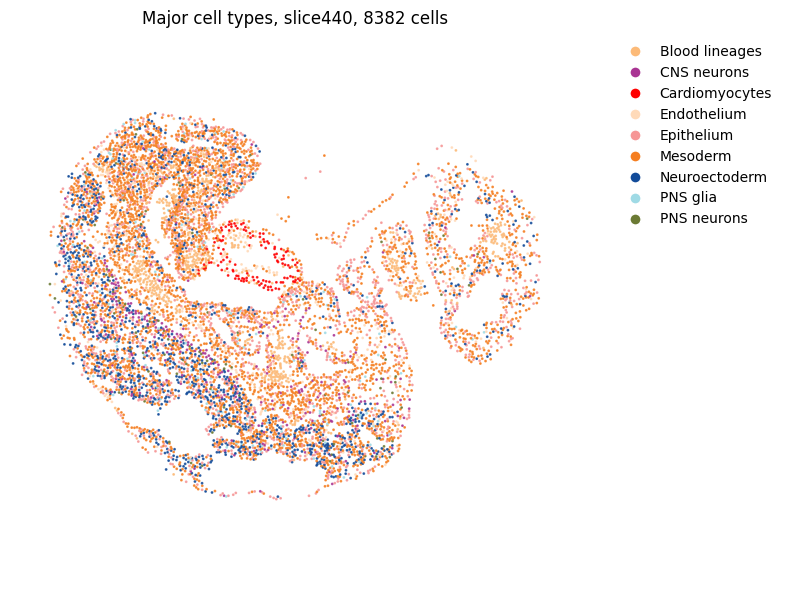

In [43]:
from matplotlib.lines import Line2D

coords = slice.obsm['global_align_spatial']
labels = slice.obs['mapped_celltype_nine']

unique_labels = sorted(labels.dropna().unique())

label_to_color = {label: major_class_colors.get(label, "#CCCCCC") for label in unique_labels}
colors = [label_to_color.get(l, "#CCCCCC") for l in labels]

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, s=1, alpha=0.8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Major cell types, slice440, {slice.shape[0]} cells')
plt.axis('equal')
plt.box(False)
plt.axis('off')

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=label_to_color[label],
        markersize=8,
        label=label
    )
    for label in unique_labels
]

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

#### Read in embeded features from original slice and generate slice.

In [17]:
emb = sc.read('logs/GAE-2D/2d/lightning_logs/version_0/embedded-all.h5ad')

In [30]:
emb

AnnData object with n_obs × n_vars = 8382 × 17649
    obsm: 'embeddings', 'spatial'

In [ ]:
res = sc.read('logs/GAE+FFN-2D/2d/lightning_logs/version_1/reconstructed-original.h5ad')

In [21]:
res

AnnData object with n_obs × n_vars = 16764 × 1
    obsm: 'fitted_embd', 'reconstructed_raw', 'spatial', 'spatial_normalized'

#### Transfer annotations based on KNN

In [31]:
emb.obs['mapped_celltype'] = slice.obs['mapped_celltype'].values

In [32]:
from scipy.spatial.distance import cdist

alpha = 0.05  # weight，0.0 = pure spatial，1.0 = pure latent gene expression,

# At the end of this tutorial, we illustrate how to choose the alpha value in order to
# balance the influence of spatial coord and latent gene expression

fitted_embd_dense = res.obsm['fitted_embd']
if hasattr(fitted_embd_dense, 'toarray'):
    fitted_embd_dense = fitted_embd_dense.toarray()

# for each point, find the nearest ref point
annotations = []
for i in range(res.shape[0]):
    d_expr = cdist(emb.obsm['embeddings'], fitted_embd_dense[i, np.newaxis, :], metric='euclidean').flatten()
    ### note that we used normalized spatial coord ###
    d_spatial = cdist(emb.obsm['spatial'], res.obsm['spatial_normalized'][i, np.newaxis, :], metric='euclidean').flatten()
    d_combined = alpha * d_expr + (1 - alpha) * d_spatial
    best_idx = d_combined.argmin()
    annotations.append(emb.obs.iloc[best_idx]['mapped_celltype'])

In [33]:
res.obs['predicted_celltype'] = annotations

Text(0.5, 1.0, 'Predicted Cell Types, Slice 440, 16764 cells')

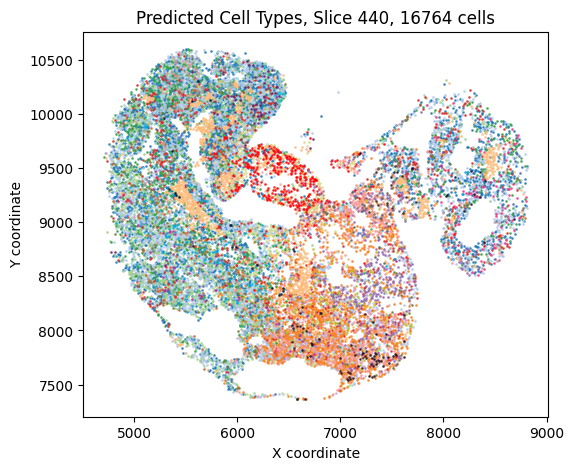

In [67]:
spatial_coords = res.obsm['spatial']
x_coords = spatial_coords[:, 0]
y_coords = spatial_coords[:, 1]

cell_types = res.obs['predicted_celltype']

# Get unique types in this slice
unique_types = cell_types.unique()
n_types = len(unique_types)

fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))

for cell_type in unique_types:
    mask = cell_types == cell_type
    ax1.scatter(x_coords[mask], y_coords[mask],
               c=[anno_colors[cell_type]],
               label=cell_type,
               s=1, alpha=0.7)

ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')
ax1.set_title(f'Predicted Cell Types, Slice 440, {res.shape[0]} cells')

#### We can also directly predict major cell types

In [38]:
emb.obs['mapped_celltype_nine'] = slice.obs['mapped_celltype_nine'].values

In [70]:
from scipy.spatial.distance import cdist

alpha = 0.05  # weight，0.0 = pure spatial，1.0 = pure gene expression

fitted_embd_dense = res.obsm['fitted_embd']
if hasattr(fitted_embd_dense, 'toarray'):
    fitted_embd_dense = fitted_embd_dense.toarray()

# for each point, find the nearest ref point
annotations = []
for i in range(res.shape[0]):
    d_expr = cdist(emb.obsm['embeddings'], fitted_embd_dense[i, np.newaxis, :], metric='euclidean').flatten()
    ### note that we used normalized spatial coord ###
    d_spatial = cdist(emb.obsm['spatial'], res.obsm['spatial_normalized'][i, np.newaxis, :], metric='euclidean').flatten()
    d_combined = alpha * d_expr + (1 - alpha) * d_spatial
    best_idx = d_combined.argmin()
    annotations.append(emb.obs.iloc[best_idx]['mapped_celltype_nine'])

In [71]:
res.obs['predicted_celltype_nine'] = annotations

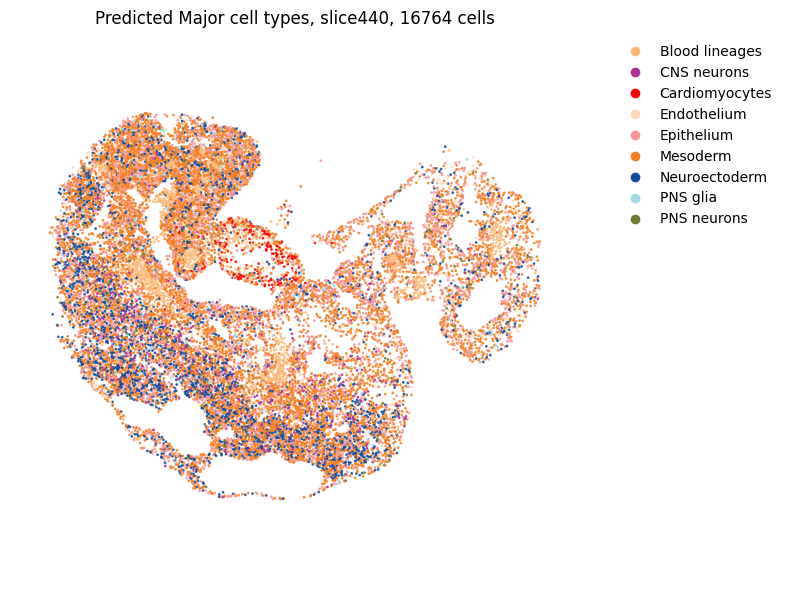

In [72]:
from matplotlib.lines import Line2D

coords = res.obsm['spatial']
labels = res.obs['predicted_celltype_nine']

unique_labels = sorted(labels.dropna().unique())

label_to_color = {label: major_class_colors.get(label, "#CCCCCC") for label in unique_labels}
colors = [label_to_color.get(l, "#CCCCCC") for l in labels]

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, s=1, alpha=0.8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Predicted Major cell types, slice440, {res.shape[0]} cells')
plt.axis('equal')
plt.box(False)
plt.axis('off')

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=label_to_color[label],
        markersize=8,
        label=label
    )
    for label in unique_labels
]

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

#### How to choose the alpha value?

In [59]:
np.median(d_expr)

np.float64(115.56246011613429)

In [60]:
np.median(d_spatial)

np.float64(0.6717270550719289)

In [51]:
mE = np.median(d_expr)
mS = np.median(d_spatial)
alpha_balanced = mS / (mE + mS + 1e-12)
alpha_balanced

np.float64(0.005779083343891829)

Alpha would need to be around 0.006 for the latent expression and spatial terms to contribute at comparable magnitudes (i.e., to have roughly equal influence in the combined distance).

In [52]:
alpha_balanced * d_expr

array([0.57150895, 0.56836565, 0.79764584, ..., 0.75834499, 0.76417003,
       0.65952493])

In [53]:
(1 - alpha_balanced) * d_spatial

array([1.06020115, 1.05720464, 1.18767899, ..., 0.32496874, 0.34960844,
       0.37166664])

In [54]:
alpha = alpha_balanced

fitted_embd_dense = res.obsm['fitted_embd']
if hasattr(fitted_embd_dense, 'toarray'):
    fitted_embd_dense = fitted_embd_dense.toarray()

# for each point, find the nearest ref point
annotations = []
for i in range(res.shape[0]):
    d_expr = cdist(emb.obsm['embeddings'], fitted_embd_dense[i, np.newaxis, :], metric='euclidean').flatten()
    ### note that we used normalized spatial coord ###
    d_spatial = cdist(emb.obsm['spatial'], res.obsm['spatial_normalized'][i, np.newaxis, :], metric='euclidean').flatten()
    d_combined = alpha * d_expr + (1 - alpha) * d_spatial
    best_idx = d_combined.argmin()
    annotations.append(emb.obs.iloc[best_idx]['mapped_celltype_nine'])

In [55]:
res.obs['predicted_celltype_nine'] = annotations

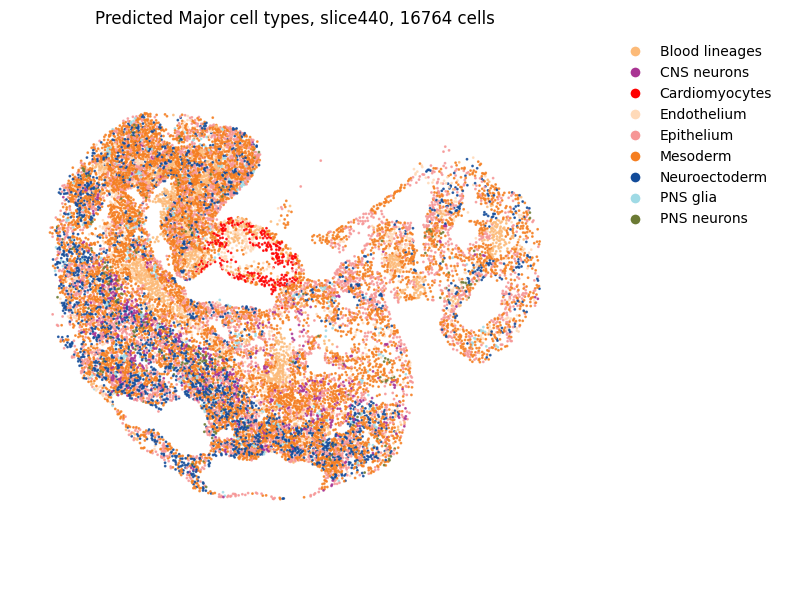

In [69]:
from matplotlib.lines import Line2D

coords = res.obsm['spatial']
labels = res.obs['predicted_celltype_nine']

unique_labels = sorted(labels.dropna().unique())

label_to_color = {label: major_class_colors.get(label, "#CCCCCC") for label in unique_labels}
colors = [label_to_color.get(l, "#CCCCCC") for l in labels]

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1], c=colors, s=1, alpha=0.8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Predicted Major cell types, slice440, {res.shape[0]} cells')
plt.axis('equal')
plt.box(False)
plt.axis('off')

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=label_to_color[label],
        markersize=8,
        label=label
    )
    for label in unique_labels
]

plt.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    frameon=False
)

plt.tight_layout()
plt.show()

#### Previously, we choose alpha= 0.05, which assigns substantially greater weight to the expression term.

In [63]:
alpha = 0.05
np.median(alpha * d_expr)

np.float64(5.778123005806715)

In [64]:
np.median((1 - alpha) * d_spatial)

np.float64(0.6381407023183324)